#### PROJECT TITLE

Health Insurance Premium Prediction Using Regression Models

#### BUSINESS PROBLEM

Insurance companies need to estimate health insurance premiums based on health risk factors such as age, BMI, smoking habits, number of children, gender, and region.

The goal of this project is to build regression models that can accurately predict health insurance premiums.

###### IMPORT LIBRARIES

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy.stats import zscore
from scipy.stats import ttest_ind

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# Evaluation Metrics
from sklearn.metrics import(r2_score,root_mean_squared_error,mean_squared_error)

# Statistical Model Analysis
import statsmodels.api as sm

# VIF
from statsmodels.stats.outliers_influence import(variance_inflation_factor)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

##### LOAD DATASET

In [3]:
insurance=pd.read_csv(r"E:\Imarticus\practice and project\insurance.csv")

In [3]:
insurance.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


##### DATA UNDERSTANDING

In [4]:
# Number of rows and columns
insurance.shape

(1338, 7)

In [5]:
# Dataset information
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# Statistical Summary
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


##### MISSING VALUES

In [7]:
#check missing values
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

##### DUPLICATE VALUES

In [8]:
insurance.duplicated().sum()

np.int64(1)

##### TARGET VARIABLE ANALYSIS

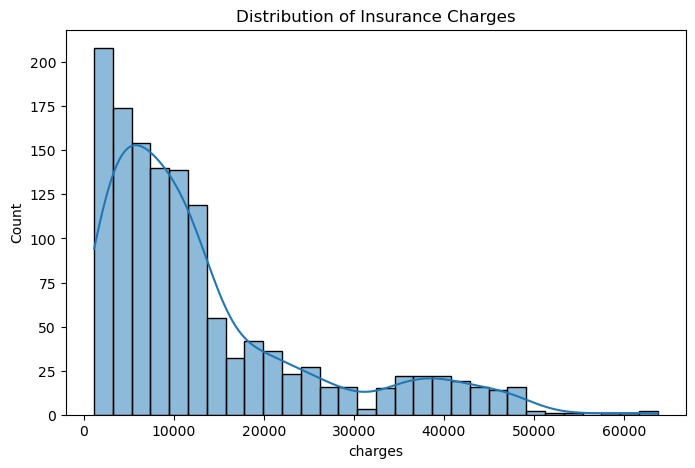

In [9]:
#Distribution of charges
plt.figure(figsize=(8,5))
sns.histplot(insurance['charges'],kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

##### Insight
Most insurance charges are concentrated
at lower values.

Distribution is positively skewed.

##### Scatter Plot Analysis

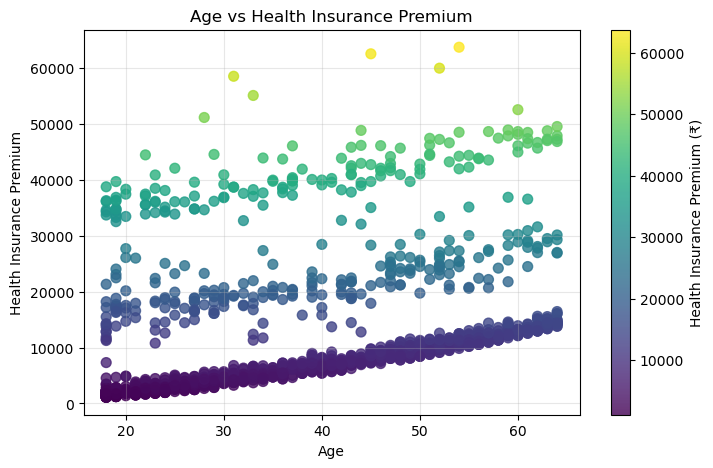

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    insurance['age'],
    insurance['charges'],
    c=insurance['charges'],      
    cmap='viridis',              
    s=50,
    alpha=0.8
)

plt.colorbar(label='Health Insurance Premium (₹)')
plt.title("Age vs Health Insurance Premium")
plt.xlabel("Age")
plt.ylabel("Health Insurance Premium")

plt.grid(alpha=0.3)
plt.show()

The scatter plot indicates that health insurance premiums generally increase with age. However, the variation in premium values shows that multiple health risk factors influence the final premium amount.

##### OUTLIER DETECTION (BOXPLOT & Z-SCORE)

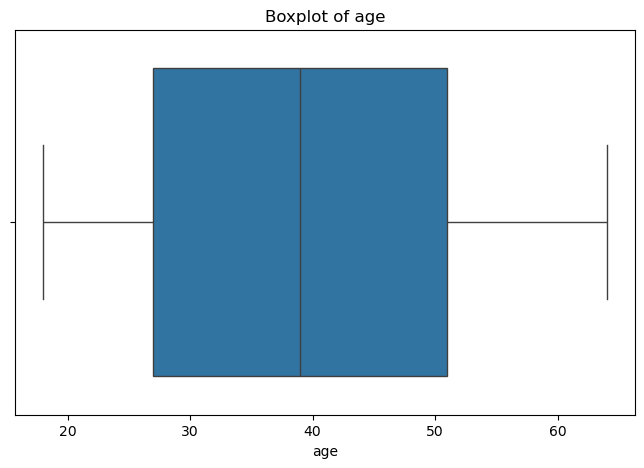

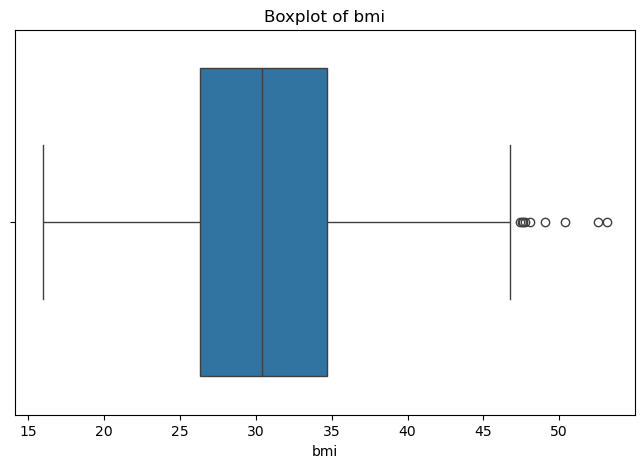

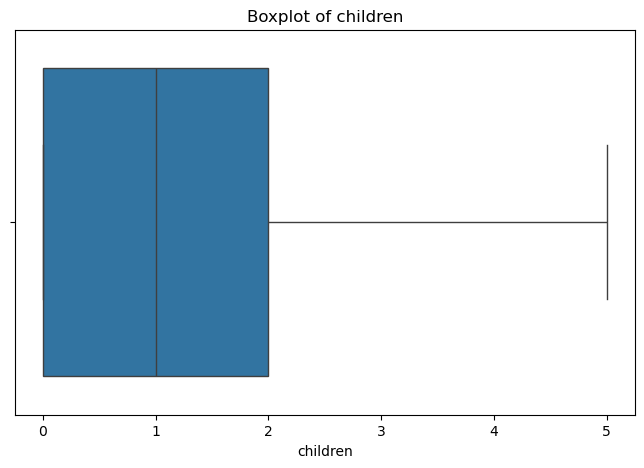

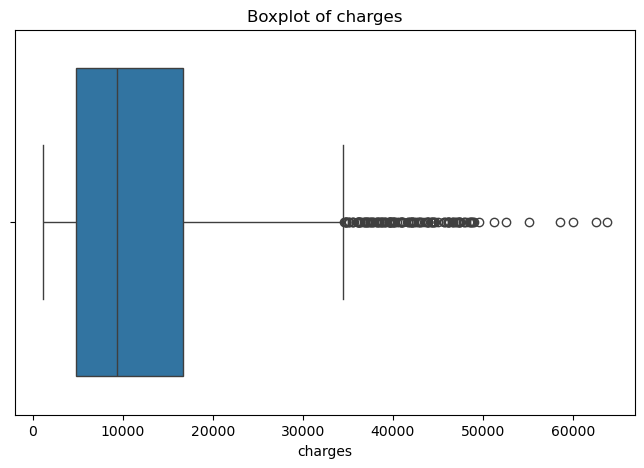

In [10]:
# Select only numerical columns
numeric_columns=insurance.select_dtypes(include=['int64','float64']).columns

# Create boxplots for all numerical columns
for col in numeric_columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=insurance[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


###### Observation
Boxplot analysis was performed on all numerical variables.

Potential outliers were identified in the BMI and Charges columns.

The Charges variable contains a significant number of extreme observations, while BMI contains a few moderate outliers.

The remaining numerical variables do not show substantial outlier presence.

In [11]:
numeric_columns=insurance.select_dtypes(include=np.number)
z_scores=np.abs(zscore(numeric_columns))
outliers=(z_scores >3).sum()
print(outliers)

29


Z Score measures how far a value is from
the mean.

|Z| > 3 indicates a potential outlier.

##### CORRELATION ANALYSIS

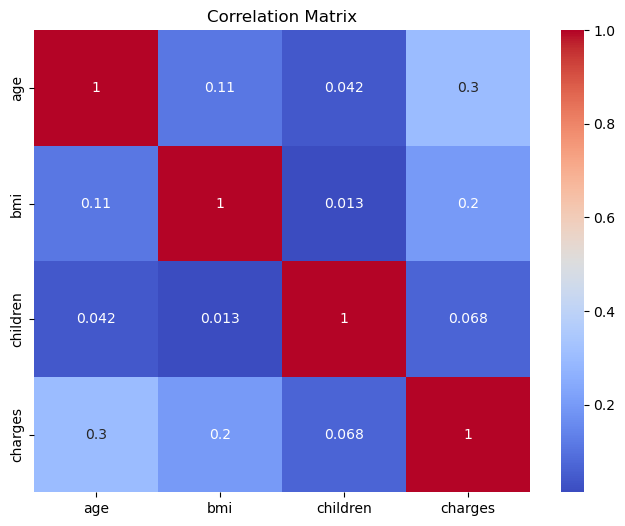

In [12]:
numeric_columns = insurance.select_dtypes(include=np.number)
corr_matrix=numeric_columns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##### correlation matrix
#age vs charges=0.30 ~ Moderate positive

#bmi vs charges=0.20 ~ Weak positive

#children vs charges=0.068(almost zero) ~ Very Weak Positive

##### Feature vs Feature
#Age vs BMI = 0.11 ~Weak relationship

#BMI vs Children = 0.013 ~ No meaningful relationship.

#Age vs Children = 0.042 ~ No meaningful relationship. 

There is no strong correlation among the independent variables, indicating low multicollinearity.

##### ENCODING

In [13]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
insurance_encoded = pd.get_dummies(insurance, drop_first=True)

insurance_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Machine Learning models require
numerical data.

Categorical columns are converted
into numeric format.

##### DEFINE FEATURES AND TARGET

In [15]:
X=insurance_encoded.drop('charges',axis=1)
y=insurance_encoded['charges']

##### TRAIN TEST SPLIT

In [16]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.20,random_state=42)

##### LINEAR REGRESSION

In [17]:
LR_Model =LinearRegression()

In [18]:
LR_Model .fit(Xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
ypred_train=LR_Model.predict(Xtrain)
ypred_test=LR_Model.predict(Xtest)

##### R2 Score    - Measures model performance

In [71]:
R2_train_score=LR_Model.score(Xtrain,ytrain)
R2_train_score

0.7417255854683333

In [72]:
R2_test_score=LR_Model.score(Xtest,ytest)
R2_test_score

0.7835929767120724

##### MSE

In [73]:
MSE_test=mean_squared_error(ytest,ypred_test)
MSE_test

33596915.851361446

##### RMSE

In [74]:
RMSE_test=root_mean_squared_error(ytest,ypred_test) #Measures prediction error in original unit.
RMSE_test

5796.284659276272

##### MAE

In [101]:
MAE_test=mean_absolute_error(ytest,ypred_test)  
MAE_test

4181.1944737536505

##### COEFFICIENT INTERPRETATION

In [76]:
coefficients=pd.DataFrame({'Features':X.columns,'Coefficient':LR_Model.coef_})
coefficients

,Features,Coefficient
0,age,256.975706
1,bmi,337.092552
2,children,425.278784
3,sex_male,-18.591692
4,smoker_yes,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


In [77]:
coefficients.sort_values(by='Coefficient',ascending=False)

,Features,Coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


Positive coefficient:
Charges increase

Negative coefficient:
Charges decrease

##### Lasso Regression

In [85]:
lasso=Lasso(alpha=1)

In [86]:
lasso.fit(Xtrain,ytrain)

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [87]:
lasso_pred = lasso.predict(Xtest)

##### R2 Score

In [91]:
lasso_train_r2 = lasso.score(Xtrain, ytrain)
lasso_train_r2

0.7417251597185028

In [90]:
lasso_test_r2 =lasso.score(Xtest,ytest) #Performs feature selection and regularization.
lasso_test_r2 

0.7835376351805537

##### MSE

In [92]:
lasso_mse = mean_squared_error(ytest, lasso_pred)
lasso_mse

33605507.553928524

##### RMSE

In [93]:
lasso_rmse = root_mean_squared_error(ytest, lasso_pred)
lasso_rmse

5797.02575066978

##### MAE

In [94]:
lasso_mae = mean_absolute_error(ytest, lasso_pred)
lasso_mae

4182.42603363668

##### Ridge Regression

In [36]:
ridge=Ridge(alpha=1)

In [37]:
ridge.fit(Xtrain,ytrain)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [95]:
ridge_pred = ridge.predict(Xtest)

##### R2 Score

In [96]:
ridge_train_r2 = ridge.score(Xtrain,ytrain) #Reduces overfitting and multicollinearity.
ridge_train_r2 

0.7417047719747443

In [97]:
ridge_test_r2 = ridge.score(Xtest, ytest)
ridge_test_r2

0.7832830144988215

##### MSE

In [98]:
ridge_mse = mean_squared_error(ytest, ridge_pred)
ridge_mse

33645037.09177902

##### RMSE

In [99]:
ridge_rmse = root_mean_squared_error(ytest, ridge_pred)
ridge_rmse

5800.434215796178

##### MAE

In [100]:
ridge_mae = mean_absolute_error(ytest, ridge_pred)
ridge_mae

4193.585298299824

##### VIF

In [39]:
vif=pd.DataFrame()

In [40]:
vif['Feature']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i)
            for i in range(X.shape[1])]

In [41]:
vif             #Checks multicollinearity.
#Rule
#VIF < 5  - Good
#VIF > 10 - Problem

,Feature,VIF
0,age,7.686965
1,bmi,11.358443
2,children,1.809930
3,sex_male,2.003185
4,smoker_yes,1.261233
5,region_northwest,1.890281
6,region_southeast,2.265564
7,region_southwest,1.960745


# FINAL CONCLUSION

This project analyzed the **Medical Insurance Charges** dataset by applying **Linear Regression, Ridge Regression, and Lasso Regression** models to predict insurance charges.

## Key Findings

- The dataset contained no missing values and was successfully preprocessed.
- Outliers were identified using the Z-Score method.
- Correlation analysis showed that **age, BMI, and smoking status** have a significant impact on medical insurance charges.
- Feature encoding and train-test splitting were performed before training the regression models.
- Linear Regression, Ridge Regression, and Lasso Regression were successfully trained and evaluated.

## Model Performance

- **Linear Regression Test R² Score:** **0.784**
- **MSE:** **33,596,915.85**
- **RMSE:** **5,796.28**
- **MAE:** **4,181.19**

## Conclusion

The regression models demonstrated good predictive performance for estimating medical insurance charges. Among the evaluated models, **Linear Regression** achieved a **Test R² Score of 0.784**, indicating that the model explains approximately **78.4%** of the variation in insurance charges. 

The analysis also identified **smoking status, BMI, age, and number of children** as the most influential factors affecting insurance costs. Overall, this project shows that regression models can effectively predict medical insurance charges and provide valuable insights for healthcare cost estimation.

#### Feature Engineering for Decision Tree

##### Age Group & BMI Category Feature


In [42]:
# Age Feature Engineering
insurance['Age_Group']=pd.cut(insurance['age'],bins=[0,30,50,100],
                              labels=['Young','Middle_Age','Senior'])

In [43]:
insurance['Age_Group'].value_counts()

Age_Group
Middle_Age    538
Young         444
Senior        356
Name: count, dtype: int64

In [44]:
# BMI Feature Engineering
insurance['BMI_Category']=pd.cut(insurance['bmi'],bins=[0,18.5,25,30,100],
                                 labels=['Underweight','Normal','Overweight','Obese'])

In [45]:
insurance['BMI_Category'].value_counts()

BMI_Category
Obese          705
Overweight     386
Normal         226
Underweight     21
Name: count, dtype: int64

In [46]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges,Age_Group,BMI_Category
0,19,female,27.900,0,yes,southwest,16884.92400,Young,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Young,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Young,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Middle_Age,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Middle_Age,Overweight


##### Encoding

In [47]:
insurance = pd.get_dummies( insurance,columns=['sex','smoker','region','Age_Group','BMI_Category'],drop_first=True)

In [48]:
insurance.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,Age_Group_Middle_Age,Age_Group_Senior,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,19,27.900,0,16884.92400,False,True,False,False,True,False,False,False,True,False
1,18,33.770,1,1725.55230,True,False,False,True,False,False,False,False,False,True
2,28,33.000,3,4449.46200,True,False,False,True,False,False,False,False,False,True
3,33,22.705,0,21984.47061,True,False,True,False,False,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False,True,False,False,True,False


##### Define X and y

In [49]:
X_dt = insurance.drop('charges', axis=1)
y_dt = insurance['charges']

##### Train Test Split

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
Xtrain_dt, Xtest_dt, ytrain_dt, ytest_dt=train_test_split(X_dt,y_dt,test_size=0.30,
                                                          random_state=42)

##### Build Decision Tree Regressor

In [52]:
from sklearn.tree import DecisionTreeRegressor

In [53]:
DT_Model=DecisionTreeRegressor(max_depth=4,min_samples_split=40,
                               min_samples_leaf=15,random_state=42)

In [54]:
X_dt=insurance.drop('charges',axis=1)
y_dt=insurance['charges']

In [55]:
Xtrain_dt, Xtest_dt, ytrain_dt, ytest_dt = train_test_split(X_dt, y_dt, test_size=0.2,
                                                            random_state=42)

In [56]:
# Check datatypes after encoding
Xtrain_dt.dtypes

age                          int64
bmi                        float64
children                     int64
sex_male                      bool
smoker_yes                    bool
region_northwest              bool
region_southeast              bool
region_southwest              bool
Age_Group_Middle_Age          bool
Age_Group_Senior              bool
BMI_Category_Normal           bool
BMI_Category_Overweight       bool
BMI_Category_Obese            bool
dtype: object

In [57]:
from sklearn.tree import DecisionTreeRegressor

In [58]:
DT_Model=DecisionTreeRegressor(max_depth=4,min_samples_split=40,
                               min_samples_leaf=15,random_state=42)

In [59]:
DT_Model.fit(Xtrain_dt,ytrain_dt)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,40
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


##### Train R2 Score

In [60]:
R2_train=DT_Model.score(Xtrain_dt, ytrain_dt)
R2_train

0.8655107523404492

##### Test R2 Score

In [61]:
R2_test=DT_Model.score(Xtest_dt, ytest_dt)
R2_test

0.8730896343414005

In [62]:
ytrain_pred=DT_Model.predict(Xtrain_dt)
ytest_pred=DT_Model.predict(Xtest_dt)

##### RMSE

In [63]:
from sklearn.metrics import root_mean_squared_error

In [104]:
DT_rmse = root_mean_squared_error(ytest_dt, ytest_pred)
DT_rmse

4438.7693431462185

##### MSE

In [105]:
DT_mse = mean_squared_error(ytest_dt, ytest_pred)
DT_mse

19702673.281654708

##### MAE

In [106]:
DT_mae = mean_absolute_error(ytest_dt, ytest_pred)
DT_mae

2634.670799340794

##### Tree Structure

In [107]:
from sklearn import tree
import matplotlib.pyplot as plt

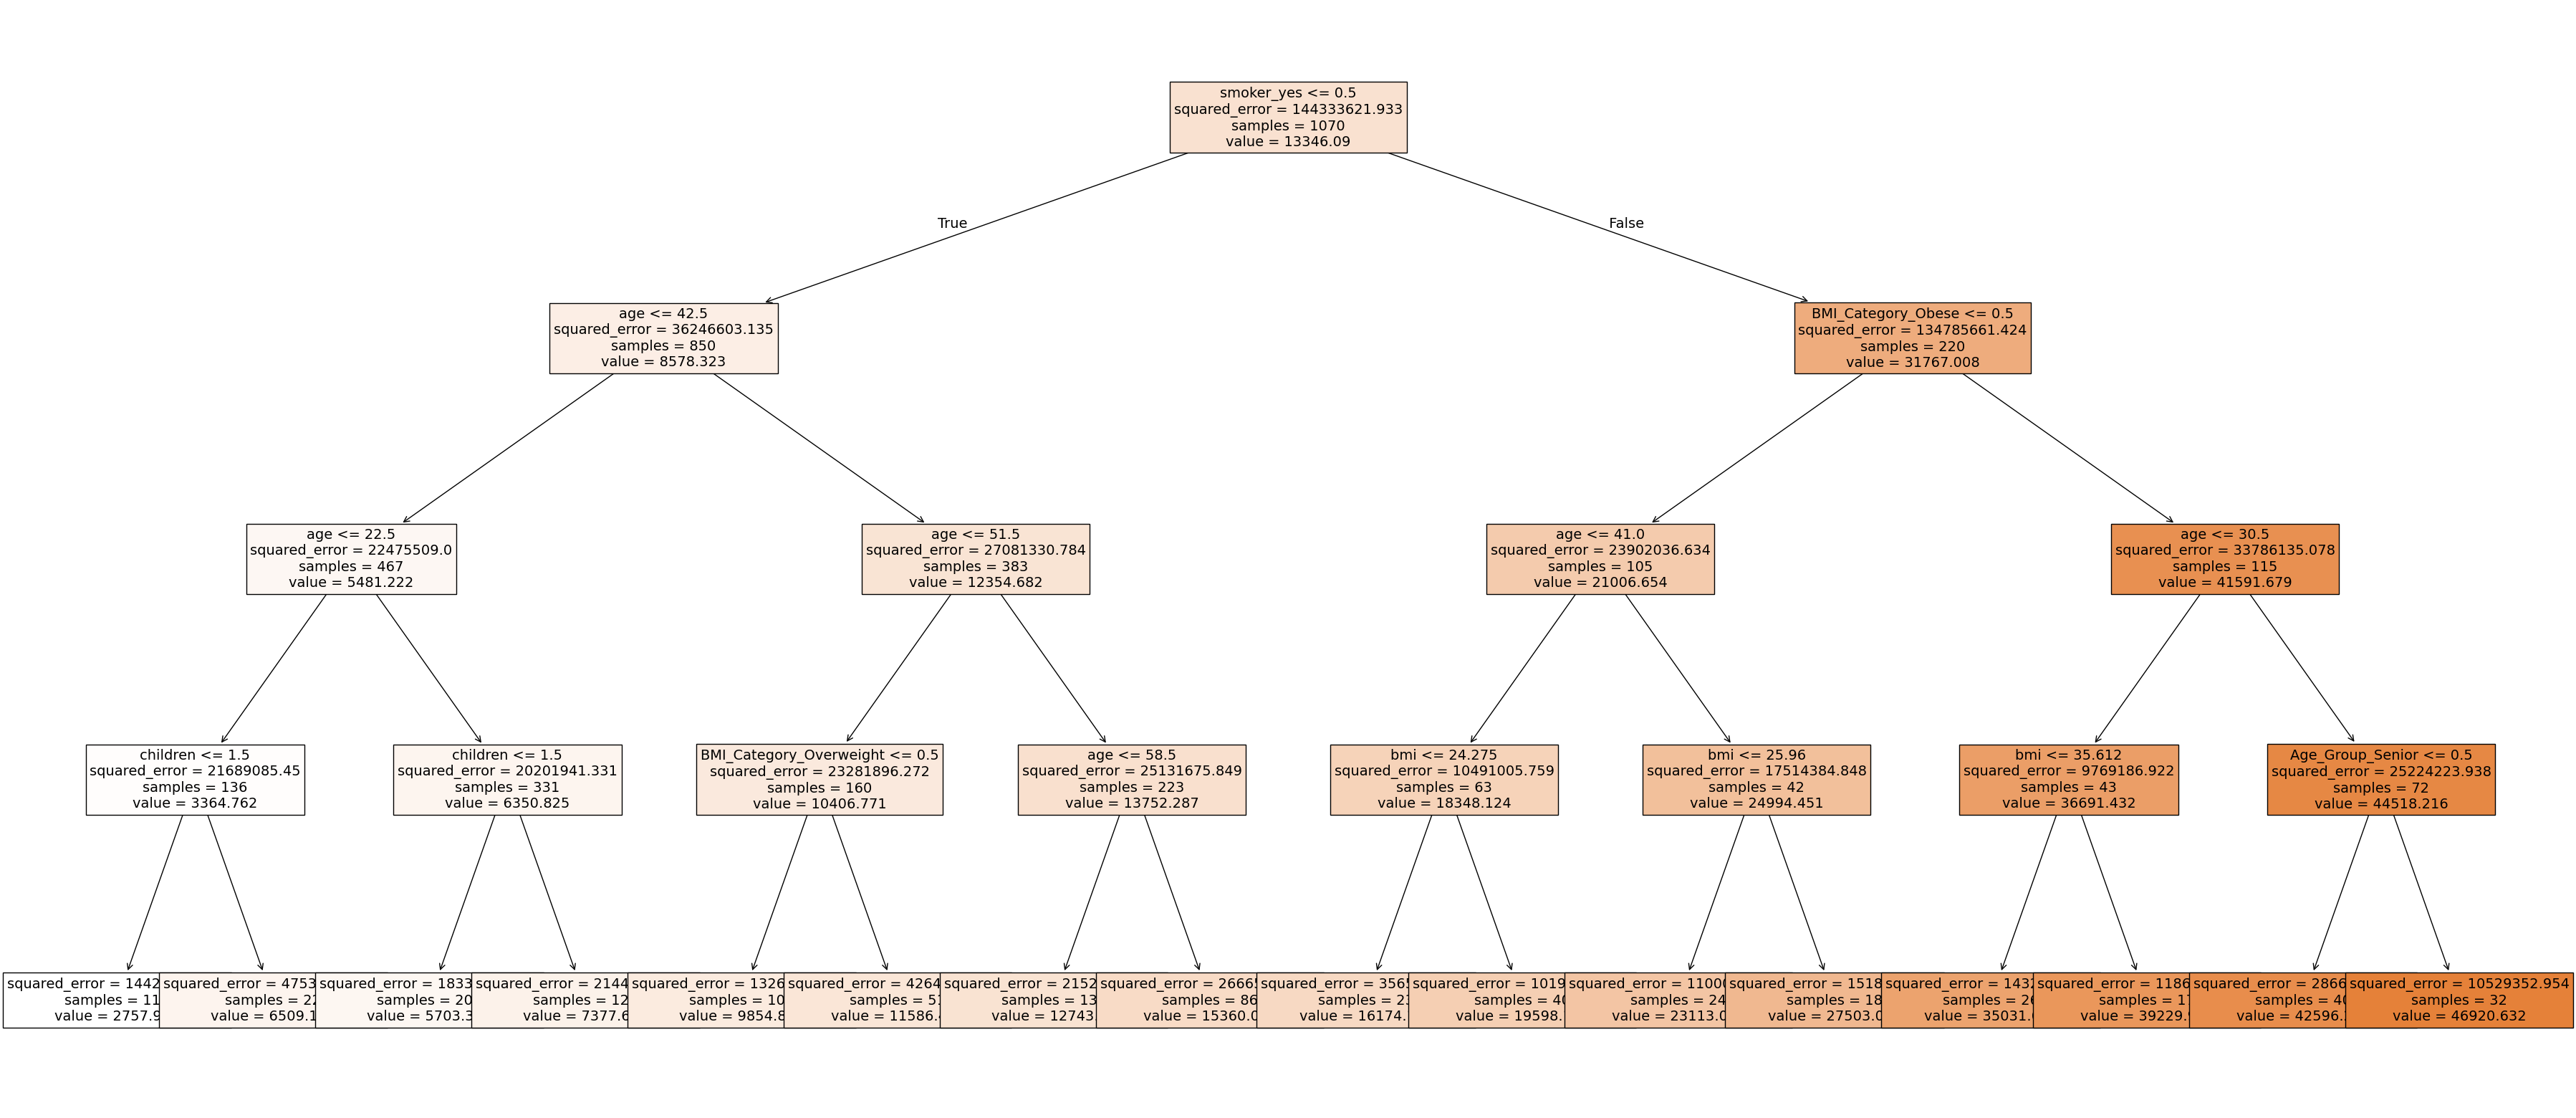

In [108]:
plt.figure(figsize=(45,20))
tree.plot_tree(DT_Model,feature_names=list(X_dt.columns),filled=True,fontsize=14);
plt.show()

# FINAL CONCLUSION

This project analyzed the **Medical Insurance Charges** dataset using a **Decision Tree Regressor** to predict insurance charges.

## Key Findings

- No missing values were found in the dataset.
- Outliers were identified and handled during data preprocessing.
- Feature engineering was performed by creating **Age Group** and **BMI Category** features.
- One-Hot Encoding was applied to convert categorical variables into numerical features.
- The Decision Tree Regressor successfully learned the relationship between the input features and insurance charges.
- Smoking status, age, BMI, and the number of children were identified as important factors influencing insurance charges.

## Model Performance

- **Train R² Score:** 0.8655
- **Test R² Score:** 0.8731
- **Test MSE:** 19,702,673.28
- **Test RMSE:** 4,438.77
- **Test MAE:** 2,634.67

## Conclusion

The Decision Tree Regressor achieved strong predictive performance with a **Test R² Score of 0.8731**, indicating that the model explains approximately **87.3%** of the variation in medical insurance charges. The model produced low prediction errors, with an **RMSE of 4,438.77** and an **MAE of 2,634.67**, demonstrating good prediction accuracy. Overall, the Decision Tree model effectively predicts medical insurance charges and identifies smoking status, age, BMI, and the number of children as the most influential factors affecting insurance costs.

## Model Comparison

In [109]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Decision Tree'],
    'Train R2 Score': [
        R2_train_score,
        ridge_train_r2,
        lasso_train_r2,
        R2_train
    ],
    'Test R2 Score': [
        R2_test_score,
        ridge_test_r2,
        lasso_test_r2,
        R2_test
    ],
    'MSE': [
        MSE_test,
        ridge_mse,
        lasso_mse,
        DT_mse
    ],
    'RMSE': [
        RMSE_test,
        ridge_rmse,
        lasso_rmse,
        DT_rmse
    ],
    'MAE': [
        MAE_test,
        ridge_mae,
        lasso_mae,
        DT_mae
    ]
})

comparison

,Model,Train R2 Score,Test R2 Score,MSE,RMSE,MAE
0,Linear Regression,0.741726,0.783593,3.359692e+07,4438.769343,4181.194474
1,Ridge Regression,0.741705,0.783283,3.364504e+07,5800.434216,4193.585298
2,Lasso Regression,0.741725,0.783538,3.360551e+07,5797.025751,4182.426034
3,Decision Tree,0.865511,0.873090,1.970267e+07,4438.769343,2634.670799


# OVERALL OBSERVATION

## Project Workflow

- Performed Exploratory Data Analysis (EDA) to understand the Medical Insurance Charges dataset.
- Handled missing values and outliers during data preprocessing.
- Applied feature engineering by creating **Age Group** and **BMI Category** features.
- Converted categorical variables into numerical format using **One-Hot Encoding**.
- Built **Linear Regression** as the baseline model.
- Applied **Ridge Regression** and **Lasso Regression** to reduce overfitting and improve model stability.
- Trained a **Decision Tree Regressor** using the engineered dataset.
- Evaluated all models using **R² Score, MSE, RMSE, and MAE**.

## Model Comparison

- **Linear Regression** achieved a Test **R² Score of 0.7836**, providing a strong baseline model.
- **Ridge Regression** produced performance similar to Linear Regression while improving model stability.
- **Lasso Regression** performed feature selection and achieved performance comparable to Ridge Regression.
- **Decision Tree Regressor** achieved the best overall performance with:
  - **Train R² Score:** 0.8655
  - **Test R² Score:** 0.8731
  - **Test MSE:** 19,702,673.28
  - **Test RMSE:** 4,438.77
  - **Test MAE:** 2,634.67
- The close Train and Test R² Scores indicate that the Decision Tree model generalized well with minimal overfitting.

## Final Observation

This project successfully developed and compared multiple machine learning regression models for predicting medical insurance charges. Among the evaluated models, the **Decision Tree Regressor** achieved the best overall performance with the highest **Test R² Score (0.8731)** and the lowest prediction errors (**MSE, RMSE, and MAE**).

The analysis also showed that **age, BMI, smoking status, and the number of children** are the most influential factors affecting medical insurance charges. Overall, this project demonstrates that machine learning regression models can effectively predict insurance costs and support data-driven decision-making in the healthcare insurance domain

